# Teil 2: Datenanalyse – Airbnb NYC 2019

In diesem Notizbuch mache ich mich mit dem Airbnb-Datensatz vertraut und bereite ihn auf die Verarbeitung vor.

In [1]:
%matplotlib inline

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

# Daten laden
df = pd.read_csv('AB_NYC_2019.csv')
print(f'Anzahl Zeilen: {len(df)}')
print(f'Anzahl Spalten: {len(df.columns)}')
df.head()

Anzahl Zeilen: 48895
Anzahl Spalten: 16


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
1,7750,Huge 2 BR Upper East Cental Park,17985,Sing,Manhattan,East Harlem,40.79685,-73.94872,Entire home/apt,190,7,0,NaN,NaN,2,249
2,8700,Magnifique Suite au N de Manhattan - vue Cloitres,26394,Claude & Sophie,Manhattan,Inwood,40.86754,-73.92639,Private room,80,4,0,NaN,NaN,1,0
3,11452,Clean and Quiet in Brooklyn,7355,Vt,Brooklyn,Bedford-Stuyvesant,40.68876,-73.94312,Private room,35,60,0,NaN,NaN,1,365
4,11943,Country space in the city,45445,Harriet,Brooklyn,Flatbush,40.63702,-73.96327,Private room,150,1,0,NaN,NaN,1,365


## 2.1 Zielfeld für Vorhersagen

Ich möchte den **Preis (price)** einer Airbnb-Unterkunft vorhersagen.

Das Feld `price` ist sinnvoll, weil es von vielen anderen Feldern abhängt, z.B.:
- **neighbourhood_group** (Stadtteil wie Manhattan, Brooklyn)
- **room_type** (ganzes Apartment, Privatzimmer, geteiltes Zimmer)
- **minimum_nights** (Mindestanzahl Nächte)
- **availability_365** (Verfügbarkeit im Jahr)

Der Preis ist ein numerisches Feld und eignet sich gut für eine Regression.

## 2.2 Statistische Informationen pro Feld

In [2]:
# Übersicht über alle numerischen Felder
print('=== Statistische Übersicht ===')
print(df.describe().round(2))

=== Statistische Übersicht ===
                id       host_id  latitude  longitude     price  \
count     48895.00  4.889500e+04  48895.00   48895.00  48895.00   
mean   19017143.24  6.762001e+07     40.73     -73.95    152.72   
std    10983108.39  7.861097e+07      0.05       0.05    240.15   
min        2539.00  2.438000e+03     40.50     -74.24      0.00   
25%     9471945.00  7.822033e+06     40.69     -73.98     69.00   
50%    19677284.00  3.079382e+07     40.72     -73.96    106.00   
75%    29152178.50  1.074344e+08     40.76     -73.94    175.00   
max    36487245.00  2.743213e+08     40.91     -73.71  10000.00   

       minimum_nights  number_of_reviews  reviews_per_month  \
count        48895.00           48895.00           38843.00   
mean             7.03              23.27               1.37   
std             20.51              44.55               1.68   
min              1.00               0.00               0.01   
25%              1.00               1.00          

In [3]:
# Detaillierte Statistiken für jedes numerische Feld
numerische_felder = ['price', 'minimum_nights', 'number_of_reviews', 
                     'reviews_per_month', 'calculated_host_listings_count', 
                     'availability_365', 'latitude', 'longitude']

for feld in numerische_felder:
    print(f'\n--- {feld} ---')
    print(f'  Mittelwert:          {df[feld].mean():.2f}')
    print(f'  Median:              {df[feld].median():.2f}')
    print(f'  Standardabweichung:  {df[feld].std():.2f}')
    print(f'  Minimum:             {df[feld].min():.2f}')
    print(f'  Maximum:             {df[feld].max():.2f}')
    print(f'  Fehlende Werte:      {df[feld].isna().sum()}')


--- price ---
  Mittelwert:          152.72
  Median:              106.00
  Standardabweichung:  240.15
  Minimum:             0.00
  Maximum:             10000.00
  Fehlende Werte:      0

--- minimum_nights ---
  Mittelwert:          7.03
  Median:              3.00
  Standardabweichung:  20.51
  Minimum:             1.00
  Maximum:             1250.00
  Fehlende Werte:      0

--- number_of_reviews ---
  Mittelwert:          23.27
  Median:              5.00
  Standardabweichung:  44.55
  Minimum:             0.00
  Maximum:             629.00
  Fehlende Werte:      0

--- reviews_per_month ---
  Mittelwert:          1.37
  Median:              0.72
  Standardabweichung:  1.68
  Minimum:             0.01
  Maximum:             58.50
  Fehlende Werte:      10052

--- calculated_host_listings_count ---
  Mittelwert:          7.14
  Median:              1.00
  Standardabweichung:  32.95
  Minimum:             1.00
  Maximum:             327.00
  Fehlende Werte:      0

--- availabilit

In [4]:
# Statistiken für kategorische Felder
print('=== Kategorische Felder ===')

print('\n--- neighbourhood_group ---')
print(df['neighbourhood_group'].value_counts())

print('\n--- room_type ---')
print(df['room_type'].value_counts())

=== Kategorische Felder ===

--- neighbourhood_group ---
neighbourhood_group
Manhattan        21661
Brooklyn         20104
Queens            5666
Bronx             1091
Staten Island      373
Name: count, dtype: int64

--- room_type ---
room_type
Entire home/apt    25409
Private room       22326
Shared room         1160
Name: count, dtype: int64


## 2.3 Grafiken

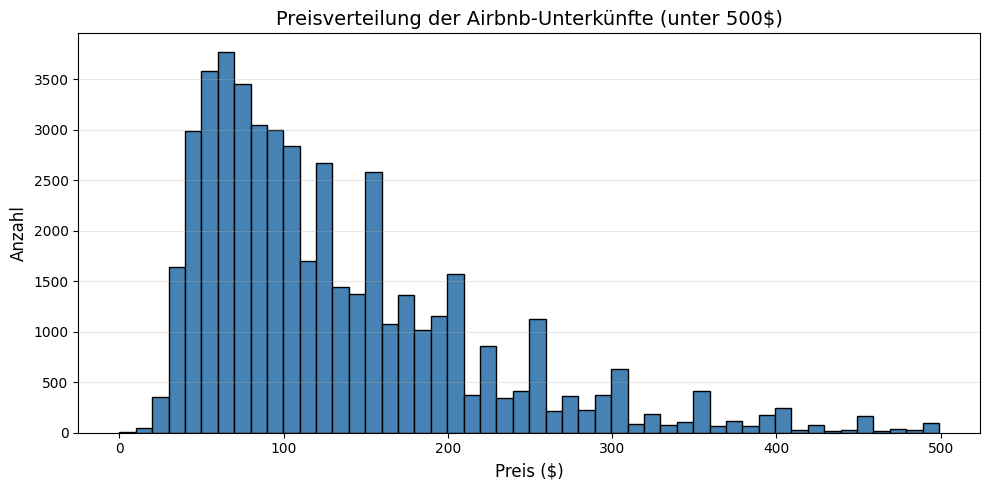

In [5]:
# Histogramm: Preisverteilung (nur Preise unter 500$ für bessere Lesbarkeit)
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df[df['price'] < 500]['price'], bins=50, color='steelblue', edgecolor='black')
ax.set_title('Preisverteilung der Airbnb-Unterkünfte (unter 500$)', fontsize=14)
ax.set_xlabel('Preis ($)', fontsize=12)
ax.set_ylabel('Anzahl', fontsize=12)
ax.grid(axis='y', alpha=0.3)
fig.tight_layout()
plt.show()

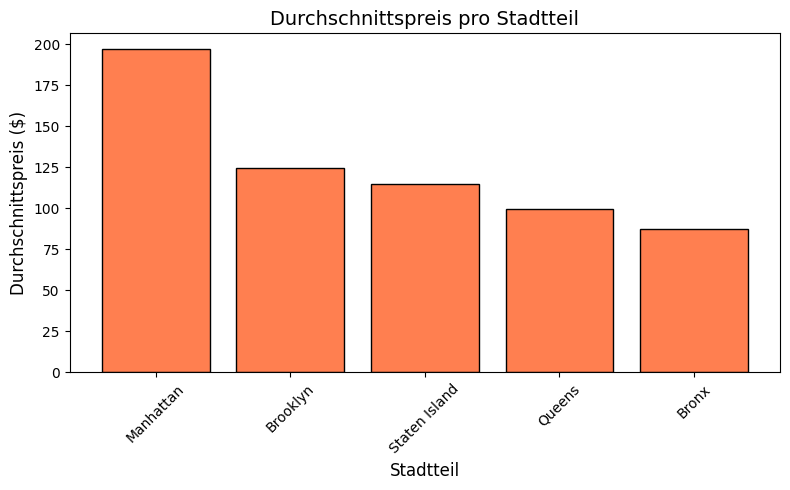

In [6]:
# Balkendiagramm: Durchschnittspreis pro Stadtteil
fig, ax = plt.subplots(figsize=(8, 5))
avg_price = df.groupby('neighbourhood_group')['price'].mean().sort_values(ascending=False)
ax.bar(avg_price.index, avg_price.values, color='coral', edgecolor='black')
ax.set_title('Durchschnittspreis pro Stadtteil', fontsize=14)
ax.set_xlabel('Stadtteil', fontsize=12)
ax.set_ylabel('Durchschnittspreis ($)', fontsize=12)
plt.xticks(rotation=45)
fig.tight_layout()
plt.show()

## 2.4 Skalierung

Ich skaliere das Feld `price` mit dem **MinMaxScaler** auf den Bereich [0, 1].

Die Skalierung ist sinnvoll, weil die numerischen Felder sehr unterschiedliche Wertebereiche haben. Zum Beispiel liegt `price` zwischen 0 und 10'000, während `latitude` zwischen 40 und 41 liegt. Ohne Skalierung würden Felder mit grossen Zahlenwerten die Machine-Learning-Algorithmen stärker beeinflussen als Felder mit kleinen Werten. Der MinMaxScaler bringt alle Werte auf den gleichen Bereich, damit alle Felder gleich gewichtet werden.

In [7]:
# Skalierung von price mit MinMaxScaler
scaler = MinMaxScaler()

df['price_skaliert'] = scaler.fit_transform(df[['price']])

print('Vor der Skalierung:')
print(f'  Min: {df["price"].min()}, Max: {df["price"].max()}')
print()
print('Nach der Skalierung:')
print(f'  Min: {df["price_skaliert"].min():.4f}, Max: {df["price_skaliert"].max():.4f}')
print()
print(df[['price', 'price_skaliert']].head(10))

Vor der Skalierung:
  Min: 0, Max: 10000

Nach der Skalierung:
  Min: 0.0000, Max: 1.0000

   price  price_skaliert
0    150          0.0150
1    190          0.0190
2     80          0.0080
3     35          0.0035
4    150          0.0150
5    130          0.0130
6    200          0.0200
7     90          0.0090
8     75          0.0075
9    200          0.0200
